1. Importe o CSV (mesmo tratamento do Projeto 2: remova as colunas extras do Naive Bayes).

In [2]:
import pandas as pd

colunas_descartadas = ["NB_Score_1","NB_Score_2"]

df_bank = pd.read_csv('BankChurners.csv', usecols=lambda col: col not in colunas_descartadas)
df_bank.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


2. Calcule a taxa de attrition geral com value_counts(normalize=True).


In [3]:
df_bank['Attrition_Flag'].value_counts(normalize=True) * 100

Attrition_Flag
Existing Customer    83.934038
Attrited Customer    16.065962
Name: proportion, dtype: float64

3. Compare a média de Total_Relationship_Count, Months_Inactive_12_mon e Contacts_Count_12_mon entre os dois grupos de Attrition_Flag (dica: groupby('Attrition_Flag').mean()).


In [4]:
df_bank.groupby('Attrition_Flag')[['Total_Relationship_Count', 'Months_Inactive_12_mon','Contacts_Count_12_mon']].mean()

,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon
Attrition_Flag,,,
Attrited Customer,3.279656,2.693301,2.972342
Existing Customer,3.914588,2.273765,2.356353


4. Gere um gráfico de barras comparando a taxa de attrition por Card_Category.


C:\Users\corpp132358\AppData\Local\Temp\ipykernel_11584\1243609088.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=taxa, x='Card_Category', y='Taxa', palette='viridis')


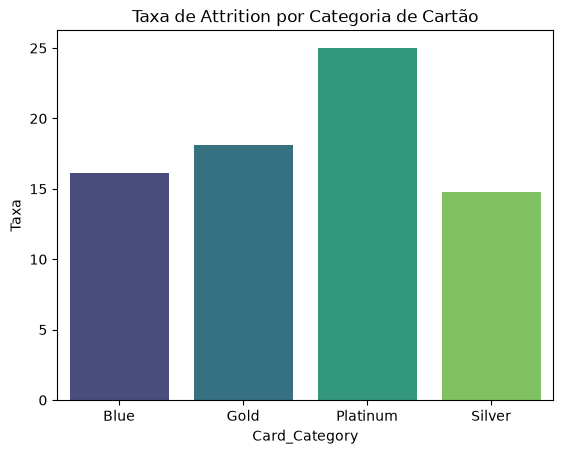

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

taxa = df_bank.groupby('Card_Category')['Attrition_Flag'].apply(lambda x: (x == 'Attrited Customer').mean() * 100).reset_index(name='Taxa')

# 2. Gera o gráfico de barras
sns.barplot(data=taxa, x='Card_Category', y='Taxa', palette='viridis')
plt.title('Taxa de Attrition por Categoria de Cartão')
plt.show()

5. Crie uma coluna nova valor_cliente combinando, de forma simples, Total_Trans_Amt e Total_Relationship_Count (ex: multiplicação ou soma normalizada) — documente sua escolha.


In [6]:
df_bank['mult_calc'] = df_bank['Total_Trans_Amt'] * df_bank['Total_Relationship_Count']

In [7]:
df_bank.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,mult_calc
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,5720
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,7746
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,7548
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,3513
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,4080


6. Liste os 10 clientes com maior valor_cliente entre os Existing Customer.


In [8]:
df_bank.query("Attrition_Flag == 'Existing Customer'").sort_values(by='mult_calc' ,ascending=False).head(10)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,mult_calc
10117,712503408,Existing Customer,57,M,2,Graduate,Married,$80K - $120K,Blue,40,...,4,17925.0,1909,16016.0,0.712,17498,111,0.820,0.106,104988
10028,778428108,Existing Customer,36,F,1,Graduate,Single,Less than $40K,Blue,16,...,3,6091.0,1184,4907.0,0.766,17437,113,0.766,0.194,104622
10014,711686658,Existing Customer,48,M,5,High School,Married,$80K - $120K,Silver,40,...,2,34516.0,1417,33099.0,0.692,16579,109,0.879,0.041,99474
9925,718496283,Existing Customer,42,F,1,College,Single,Unknown,Silver,31,...,3,30770.0,2228,28542.0,0.712,15998,121,0.704,0.072,95988
10111,710734308,Existing Customer,49,M,1,Graduate,Single,$60K - $80K,Blue,40,...,3,6481.0,1569,4912.0,0.692,15937,119,0.803,0.242,95622
9825,721438233,Existing Customer,39,M,2,Post-Graduate,Single,$40K - $60K,Blue,31,...,3,3297.0,1761,1536.0,0.879,15580,120,0.739,0.534,93480
9958,824160333,Existing Customer,56,M,2,High School,Unknown,$120K +,Blue,52,...,2,23362.0,1453,21909.0,0.848,15399,116,0.841,0.062,92394
9967,715199808,Existing Customer,39,F,3,Graduate,Unknown,Unknown,Silver,30,...,5,33905.0,2070,31835.0,0.685,15335,99,0.768,0.061,92010
9844,708759408,Existing Customer,48,F,3,Uneducated,Single,$40K - $60K,Blue,39,...,2,4207.0,0,4207.0,0.923,15124,108,0.714,0.000,90744
10059,708447858,Existing Customer,59,F,2,Uneducated,Married,Less than $40K,Blue,36,...,2,3850.0,0,3850.0,0.509,15107,117,0.918,0.000,90642


7. Gere um boxplot de Months_Inactive_12_mon separado por Attrition_Flag e comente se há diferença visível entre os grupos.


C:\Users\corpp132358\AppData\Local\Temp\ipykernel_11584\3524249732.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bank, x='Attrition_Flag', y='Months_Inactive_12_mon', palette='Set2')


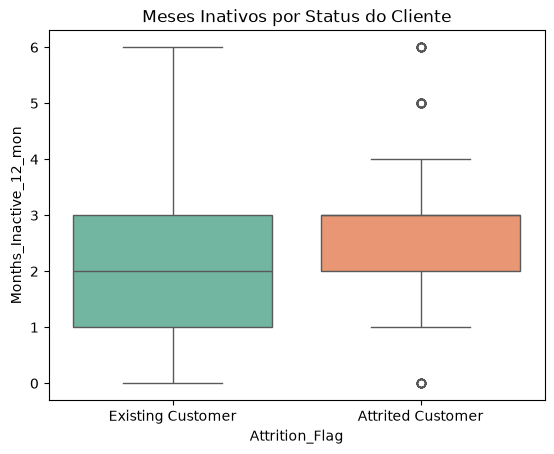

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gera o boxplot
sns.boxplot(data=df_bank, x='Attrition_Flag', y='Months_Inactive_12_mon', palette='Set2')
plt.title('Meses Inativos por Status do Cliente')
plt.show()

-- Visualmente, você notará se os clientes que cancelaram (Attrited Customer) passam mais meses inativos que os ativos (Existing Customer).

8. Combine dois filtros: quantos clientes têm Total_Relationship_Count baixo (≤ 2) *e* já saíram do banco (Attrited Customer)? Isso sugere alguma relação entre poucos produtos e attrition?


In [10]:
len(df_bank.query("Total_Relationship_Count <= 2 and Attrition_Flag == 'Attrited Customer'"))

579

-- Clientes que possuem menos produtos ou um menor engajamento com o banco (Total_Relationship_Count baixo) tendem a apresentar taxas de cancelamento (attrition) significativamente mais altas, pois possuem menor custo de troca ou menor vínculo com a instituição financeira.